<a href="https://colab.research.google.com/github/AmalKhairalla/Online-News-Popularity/blob/main/Task%20A%20%E2%80%94%20Classification/Logistic_Regression_(L1_L2_regularization).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
from google.colab import drive
drive.mount('/content/drive')

import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

SAVE_PATH = "/content/drive/MyDrive/ML_Project_Classification"

X_train_scaled = joblib.load(f"{SAVE_PATH}/X_train_scaled.pkl")
X_test_scaled = joblib.load(f"{SAVE_PATH}/X_test_scaled.pkl")
y_train = joblib.load(f"{SAVE_PATH}/y_train.pkl")
y_test = joblib.load(f"{SAVE_PATH}/y_test.pkl")

print("Loaded successfully!")
print("X_train:", X_train_scaled.shape)
print("X_test:", X_test_scaled.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Loaded successfully!
X_train: (31715, 15)
X_test: (7929, 15)
y_train: (31715,)
y_test: (7929,)


In [5]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=3000, random_state=42)
model.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=3000, random_state=42)


========== Logistic Regression L2 Baseline ==========
              precision    recall  f1-score   support

           0       0.64      0.63      0.63      4017
           1       0.62      0.63      0.63      3912

    accuracy                           0.63      7929
   macro avg       0.63      0.63      0.63      7929
weighted avg       0.63      0.63      0.63      7929

                             Model  Accuracy  Precision    Recall  F1-score  \
0  Logistic Regression L2 Baseline  0.630092   0.622836  0.634458  0.628593   

    ROC-AUC    PR-AUC  Brier Score       MCC  
0  0.670284  0.655394     0.228099  0.260279  

========== Logistic Regression L1 Baseline ==========
              precision    recall  f1-score   support

           0       0.64      0.63      0.63      4017
           1       0.62      0.63      0.63      3912

    accuracy                           0.63      7929
   macro avg       0.63      0.63      0.63      7929
weighted avg       0.63      0.63     

,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC,PR-AUC,Brier Score,MCC
0,Logistic Regression L2 Baseline,0.630092,0.622836,0.634458,0.628593,0.670284,0.655394,0.228099,0.260279
1,Logistic Regression L1 Baseline,0.629461,0.622362,0.633180,0.627724,0.670299,0.655456,0.228093,0.258999


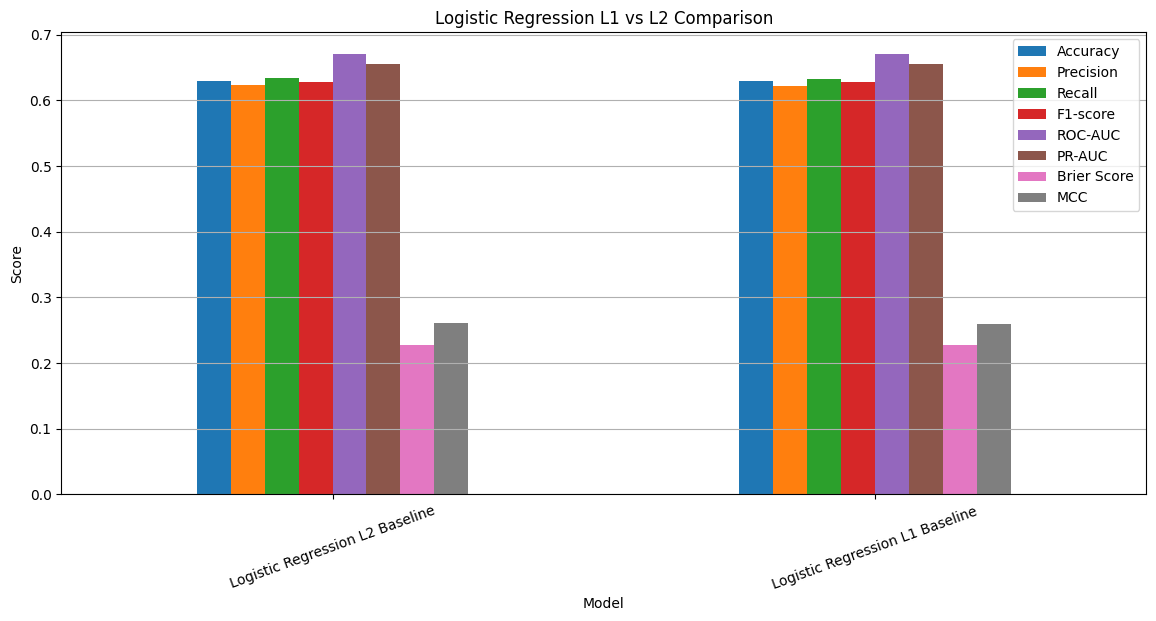

In [7]:
# ============================================================
# Logistic Regression L1/L2 Complete Section
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import (
    GridSearchCV,
    RandomizedSearchCV,
    StratifiedKFold,
    learning_curve,
    cross_val_score
)
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    PrecisionRecallDisplay,
    classification_report,
    matthews_corrcoef,
    brier_score_loss
)
from sklearn.calibration import CalibrationDisplay
from scipy.stats import loguniform


# ============================================================
# 1) Evaluation Function
# ============================================================

def evaluate_classifier(model, X_test, y_test, model_name="Model"):
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    results = {
        "Model": model_name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-score": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_proba),
        "PR-AUC": average_precision_score(y_test, y_proba),
        "Brier Score": brier_score_loss(y_test, y_proba),
        "MCC": matthews_corrcoef(y_test, y_pred)
    }

    print(f"\n========== {model_name} ==========")
    print(classification_report(y_test, y_pred))
    print(pd.DataFrame([results]))

    return results


# ============================================================
# 2) Logistic Regression L2 Baseline
# ============================================================

log_l2 = Pipeline([
    # Removed StandardScaler() because X_train_scaled is already scaled
    ("model", LogisticRegression(
        penalty="l2",
        solver="lbfgs",
        C=0.1,
        max_iter=5000,
        random_state=42
    ))
])

log_l2.fit(X_train_scaled, y_train) # Changed X_train to X_train_scaled
results_l2 = evaluate_classifier(log_l2, X_test_scaled, y_test, "Logistic Regression L2 Baseline") # Changed X_test to X_test_scaled


# ============================================================
# 3) Logistic Regression L1 Baseline
# ============================================================

log_l1 = Pipeline([
    # Removed StandardScaler() because X_train_scaled is already scaled
    ("model", LogisticRegression(
        penalty="l1",
        solver="liblinear",
        C=1.0,
        max_iter=5000,
        random_state=42
    ))
])

log_l1.fit(X_train_scaled, y_train) # Changed X_train to X_train_scaled
results_l1 = evaluate_classifier(log_l1, X_test_scaled, y_test, "Logistic Regression L1 Baseline") # Changed X_test to X_test_scaled


# ============================================================
# 4) Compare L1 vs L2
# ============================================================

comparison_df = pd.DataFrame([results_l2, results_l1])
display(comparison_df)

comparison_df.set_index("Model")[[
    "Accuracy", "Precision", "Recall", "F1-score", "ROC-AUC", "PR-AUC", "Brier Score", "MCC"
]].plot(kind="bar", figsize=(14, 6))

plt.title("Logistic Regression L1 vs L2 Comparison")
plt.ylabel("Score")
plt.xticks(rotation=20)
plt.grid(axis="y")
plt.show()